## Financial Fraud Detection

In [34]:
import pandas as pd

df = pd.read_csv("financial_fraud_detection_dataset.csv")

df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [35]:
df.shape

(5000000, 18)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), float64(4), int64(1), object(1

In [37]:
df.isnull().sum()

transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64

In [38]:
df.columns

Index(['transaction_id', 'timestamp', 'sender_account', 'receiver_account',
       'amount', 'transaction_type', 'merchant_category', 'location',
       'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction',
       'spending_deviation_score', 'velocity_score', 'geo_anomaly_score',
       'payment_channel', 'ip_address', 'device_hash'],
      dtype='object')

In [39]:
df.describe()

,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score
count,5.000000e+06,4.103487e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,3.589343e+02,1.525799e+00,-3.881160e-04,1.050132e+01,5.000293e-01
std,4.699333e+02,3.576569e+03,1.000807e+00,5.766842e+00,2.886349e-01
min,1.000000e-02,-8.777814e+03,-5.260000e+00,1.000000e+00,0.000000e+00
25%,2.657000e+01,-2.562376e+03,-6.800000e-01,5.000000e+00,2.500000e-01
50%,1.386700e+02,8.442747e-01,0.000000e+00,1.100000e+01,5.000000e-01
75%,5.038900e+02,2.568339e+03,6.700000e-01,1.600000e+01,7.500000e-01
max,3.520570e+03,8.757758e+03,5.020000e+00,2.000000e+01,1.000000e+00


In [40]:
df['amount'].describe()

count    5.000000e+06
mean     3.589343e+02
std      4.699333e+02
min      1.000000e-02
25%      2.657000e+01
50%      1.386700e+02
75%      5.038900e+02
max      3.520570e+03
Name: amount, dtype: float64

<Axes: >

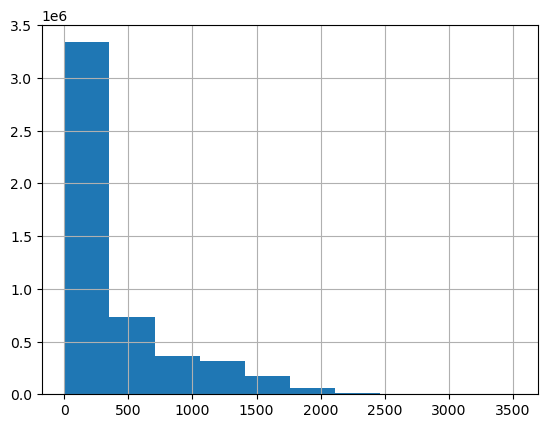

In [41]:
df['amount'].hist()

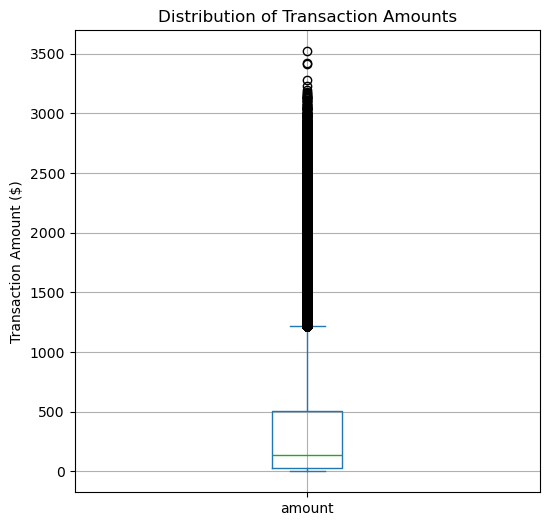

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

ax = df['amount'].plot(kind='box')

plt.title('Distribution of Transaction Amounts')
plt.ylabel('Transaction Amount ($)')

ax.set_xlabel('')   

plt.grid(True)

plt.savefig('transaction_amount_boxplot.png', dpi=300, bbox_inches='tight')

plt.show()

<Figure size 600x600 with 0 Axes>

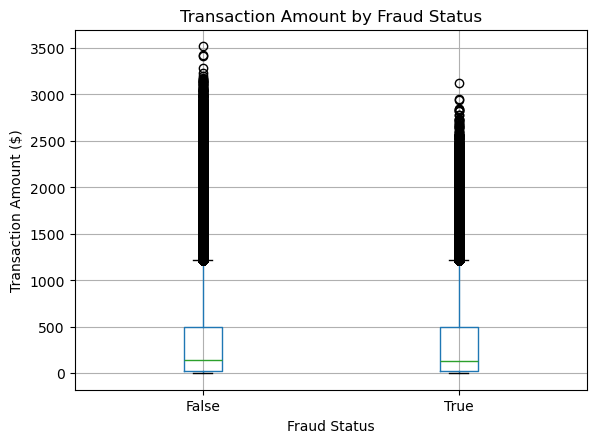

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

ax = df.boxplot(column='amount', by='is_fraud')

plt.title('Transaction Amount by Fraud Status')
plt.suptitle('')  
plt.ylabel('Transaction Amount ($)')
plt.xlabel('Fraud Status')

plt.grid(True)


plt.savefig('amount_by_fraud_boxplot.png', dpi=300, bbox_inches='tight')

plt.show()

In [44]:
df['velocity_score'].describe()

count    5.000000e+06
mean     1.050132e+01
std      5.766842e+00
min      1.000000e+00
25%      5.000000e+00
50%      1.100000e+01
75%      1.600000e+01
max      2.000000e+01
Name: velocity_score, dtype: float64

<Axes: title={'center': 'velocity_score'}, xlabel='is_fraud'>

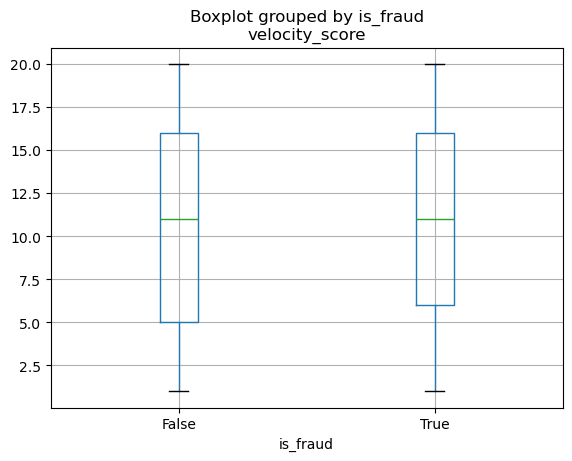

In [45]:
df.boxplot(column='velocity_score', by='is_fraud')

## Predictive Modelling

#### Data Preparation


In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report



#### Load Dataset

In [47]:
df = pd.read_csv("financial_fraud_detection_dataset.csv")


#### Take a working sample for modeling

In [48]:
df_sample = df.sample(n=100000, random_state=42)

#### Drop high-cardinality 
A sample of 100,000 records was used for model building to reduce computational load.
High-cardinality identifier-like columns were removed before encoding.

In [49]:
cols_to_drop = [
    "transaction_id",
    "timestamp",
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash",
    "fraud_type"
]

X = df_sample.drop(columns=cols_to_drop + ["is_fraud"])
y = df_sample["is_fraud"]


#### To handle missing values
Numeric missing values were filled with the median, and categorical missing values were filled with "Unknown.

In [50]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Unknown")


#### One hot encode catergorical variables.

In [51]:
X = pd.get_dummies(X, drop_first=True)

print("Remaining NaNs:", X.isnull().sum().sum())

Remaining NaNs: 0


#### Train/Test Split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


#### Model 1: Logistic Regression
Logistic Regression with class balancing was used as the baseline model.

In [53]:
print("\nLogistic Regression Results")
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))


Logistic Regression Results
              precision    recall  f1-score   support

       False       0.96      0.52      0.68     19275
        True       0.04      0.48      0.07       725

    accuracy                           0.52     20000
   macro avg       0.50      0.50      0.37     20000
weighted avg       0.93      0.52      0.66     20000



##### Radom Forest
Random Forest was used as a comparison model to evaluate whether a more complex classifier improved fraud detection.

In [54]:
print("\nRandom Forest Results")
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, zero_division=0))


Random Forest Results
              precision    recall  f1-score   support

       False       0.96      1.00      0.98     19275
        True       0.00      0.00      0.00       725

    accuracy                           0.96     20000
   macro avg       0.48      0.50      0.49     20000
weighted avg       0.93      0.96      0.95     20000



#### Logistic regression threshold tuning
Threshold tuning was applied to Logistic Regression to examine the tradeoff between fraud recall and false positives.

In [55]:
print("\nThreshold Tuning for Logistic Regression")
y_probs = model.predict_proba(X_test)[:, 1]

for t in [0.5, 0.4, 0.3, 0.2]:
    y_pred_custom = (y_probs > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_custom, zero_division=0))


Threshold Tuning for Logistic Regression

Threshold: 0.5
              precision    recall  f1-score   support

       False       0.96      0.52      0.68     19275
        True       0.04      0.48      0.07       725

    accuracy                           0.52     20000
   macro avg       0.50      0.50      0.37     20000
weighted avg       0.93      0.52      0.66     20000


Threshold: 0.4
              precision    recall  f1-score   support

       False       1.00      0.00      0.00     19275
        True       0.04      1.00      0.07       725

    accuracy                           0.04     20000
   macro avg       0.52      0.50      0.04     20000
weighted avg       0.97      0.04      0.00     20000


Threshold: 0.3
              precision    recall  f1-score   support

       False       0.00      0.00      0.00     19275
        True       0.04      1.00      0.07       725

    accuracy                           0.04     20000
   macro avg       0.02      0.50     

Logistic Regression performed better than Random Forest for fraud detection because it was able to identify
fraudulent transactions, although precision was low. Random Forest achieved higher accuracy, but failed to detect
fraud cases, demonstrating that accuracy alone is not reliable for imbalanced datasets. Threshold tuning increased
false positives, highlighting the tradeoff between recall and precision.


## Model Performance Bar Chart

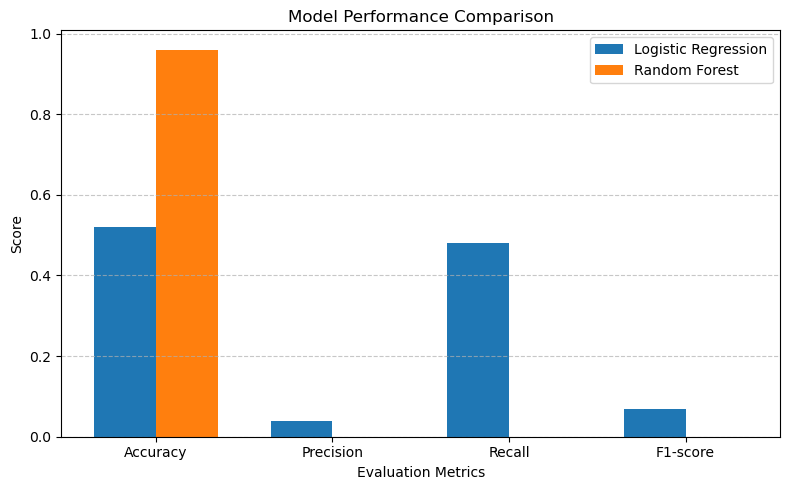

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Labels
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# Fraud detection values
log_reg_scores = [0.52, 0.04, 0.48, 0.07]
rf_scores = [0.96, 0.00, 0.00, 0.00]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, log_reg_scores, width, label='Logistic Regression')
plt.bar(x + width/2, rf_scores, width, label='Random Forest')

plt.xticks(x, metrics)
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Logistic Regression

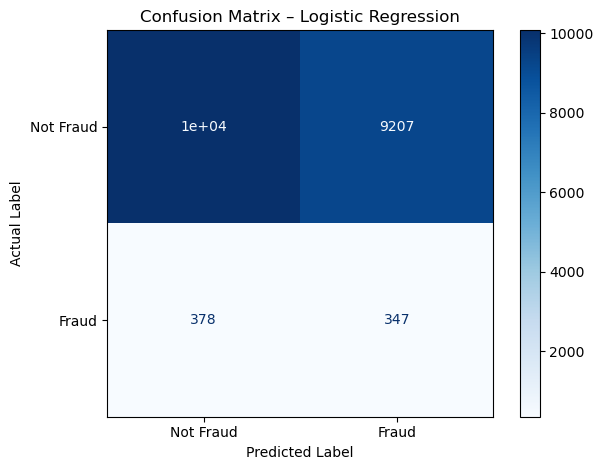

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues')

plt.title('Confusion Matrix – Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()
plt.show()

## Confusion Matrix

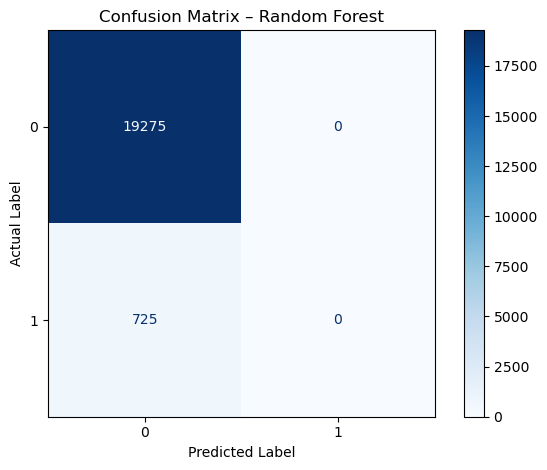

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap='Blues')

plt.title('Confusion Matrix – Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()
plt.show()

## ROC Curve

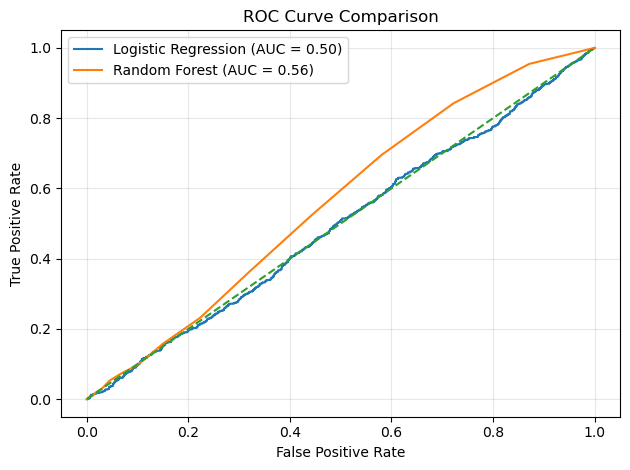

In [59]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_lr = model.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)


plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Feature Importance Chart

In [63]:
import pandas as pd

feature_importances = rf.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

feat_df = feat_df.sort_values(by='Importance', ascending=False)

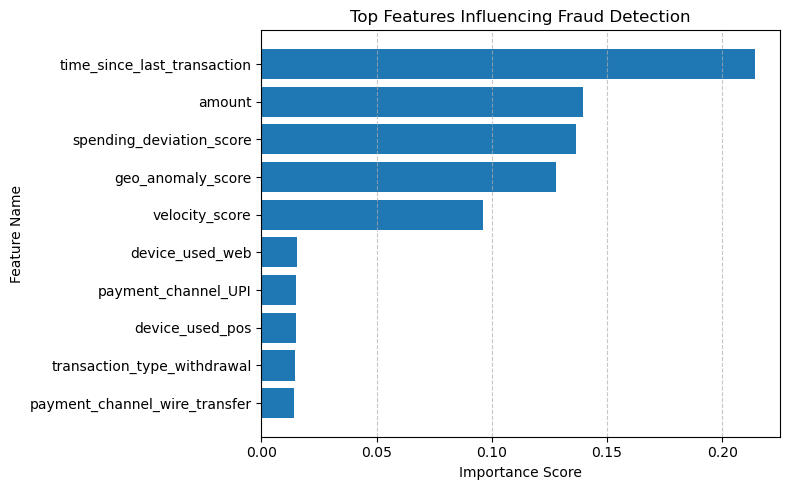

In [65]:
plt.figure(figsize=(8,5))

# Keep only top 10 features
feat_df_top = feat_df.head(10)

plt.barh(feat_df_top['Feature'], feat_df_top['Importance'])

plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.title('Top Features Influencing Fraud Detection')

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [62]:
plt.savefig('model_performance.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>